In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
iris = sns.load_dataset('iris')

print(iris.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [5]:
titanic = sns.load_dataset('titanic')

print(titanic.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


# SECTION 1
### 1. T test

In [6]:

# ============================================
# ONE-SAMPLE T-TEST ON IRIS DATASET
# ============================================

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.datasets import load_iris


# --------------------------------------------
# 1. LOAD IRIS DATASET
# --------------------------------------------

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=[
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)"
    ]
)


# --------------------------------------------
# 2. SELECT SAMPLE
# --------------------------------------------

sample = df["sepal length (cm)"].values


# --------------------------------------------
# 3. SAMPLE SIZE
# --------------------------------------------

n = len(sample)

print("Sample size (n) =", n)


# --------------------------------------------
# 4. SAMPLE MEAN
# --------------------------------------------

mean = np.mean(sample)

print("\nSample Mean =", mean)


# --------------------------------------------
# 5. SAMPLE STANDARD DEVIATION
# --------------------------------------------

# ddof=1 gives sample standard deviation

s = np.std(sample, ddof=1)

print("Sample Standard Deviation =", s)


# --------------------------------------------
# 6. HYPOTHESIZED POPULATION MEAN
# --------------------------------------------

mu0 = 5

print("Hypothesized Mean =", mu0)


# --------------------------------------------
# 7. HYPOTHESIS
# --------------------------------------------

# H0: μ = 5
#
# Two-tailed:
# H1: μ != 5
#
# One-tailed (right):
# H1: μ > 5
#
# One-tailed (left):
# H1: μ < 5


# --------------------------------------------
# 8. STANDARD ERROR
# --------------------------------------------

SE = s / np.sqrt(n)

print("\nStandard Error =", SE)


# --------------------------------------------
# 9. CALCULATE t-STATISTIC
# --------------------------------------------

t_stat = (mean - mu0) / SE

print("t-statistic =", t_stat)


# --------------------------------------------
# 10. DEGREE OF FREEDOM
# --------------------------------------------

df_t = n - 1

print("Degree of Freedom =", df_t)


# ============================================
# 11. SIGNIFICANCE LEVEL
# ============================================

alpha = 0.05

alpha_half = alpha / 2

print("\nAlpha =", alpha)
print("Alpha/2 =", alpha_half)


# ============================================
# 12. TWO-TAILED TEST
# ============================================

# Since alpha = 0.05:
#
# Each tail gets:
#
# 0.05 / 2 = 0.025


# Critical t-value

critical_t = stats.t.ppf(1 - alpha_half, df_t)

print("Critical t-value =", critical_t)

print("Critical region:")
print("t < -", critical_t, "or t >", critical_t)


# --------------------------------------------
# TWO-TAILED DECISION
# --------------------------------------------

if abs(t_stat) > critical_t:
    print("Two-tailed: Reject H0")
else:
    print("Two-tailed: Fail to reject H0")


# ============================================
# 13. ONE-TAILED RIGHT TEST
# ============================================

# H0: μ <= 5
# H1: μ > 5

p_right = stats.t.sf(t_stat, df_t)

print("\nRight-tailed p-value =", p_right)


if p_right < alpha:
    print("Right-tailed: Reject H0")
else:
    print("Right-tailed: Fail to reject H0")


# ============================================
# 14. ONE-TAILED LEFT TEST
# ============================================

# H0: μ >= 5
# H1: μ < 5

p_left = stats.t.cdf(t_stat, df_t)

print("\nLeft-tailed p-value =", p_left)


if p_left < alpha:
    print("Left-tailed: Reject H0")
else:
    print("Left-tailed: Fail to reject H0")


# ============================================
# 15. FINAL RESULTS
# ============================================

print("\n====================================")
print("FINAL RESULTS")
print("====================================")

print("Sample Size         =", n)
print("Sample Mean         =", mean)
print("Sample SD           =", s)

print("Hypothesized Mean   =", mu0)

print("Standard Error      =", SE)

print("t-statistic         =", t_stat)
print("Degree of Freedom   =", df_t)

print("Alpha               =", alpha)
print("Alpha/2             =", alpha_half)

print("Critical t-value    =", critical_t)

print("Right-tail p-value  =", p_right)
print("Left-tail p-value   =", p_left)

print("====================================")

Sample size (n) = 150

Sample Mean = 5.843333333333334
Sample Standard Deviation = 0.828066127977863
Hypothesized Mean = 5

Standard Error = 0.0676113162275986
t-statistic = 12.473257146694761
Degree of Freedom = 149

Alpha = 0.05
Alpha/2 = 0.025
Critical t-value = 1.976013177679155
Critical region:
t < - 1.976013177679155 or t > 1.976013177679155
Two-tailed: Reject H0

Right-tailed p-value = 3.3353711499009633e-25
Right-tailed: Reject H0

Left-tailed p-value = 1.0
Left-tailed: Fail to reject H0

FINAL RESULTS
Sample Size         = 150
Sample Mean         = 5.843333333333334
Sample SD           = 0.828066127977863
Hypothesized Mean   = 5
Standard Error      = 0.0676113162275986
t-statistic         = 12.473257146694761
Degree of Freedom   = 149
Alpha               = 0.05
Alpha/2             = 0.025
Critical t-value    = 1.976013177679155
Right-tail p-value  = 3.3353711499009633e-25
Left-tail p-value   = 1.0


In [7]:
# ============================================
# TWO-SAMPLE T-TEST ON IRIS DATASET
# ============================================

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.datasets import load_iris


# --------------------------------------------
# 1. LOAD IRIS DATASET
# --------------------------------------------

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=[
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)"
    ]
)

df["species"] = iris.target


# --------------------------------------------
# 2. SELECT TWO INDEPENDENT SAMPLES
# --------------------------------------------

# Setosa = 0
# Versicolor = 1

sample1 = df[df["species"] == 0]["sepal length (cm)"].values
sample2 = df[df["species"] == 1]["sepal length (cm)"].values


# --------------------------------------------
# 3. SAMPLE SIZE
# --------------------------------------------

n1 = len(sample1)
n2 = len(sample2)

print("n1 =", n1)
print("n2 =", n2)


# --------------------------------------------
# 4. CALCULATE SAMPLE MEANS
# --------------------------------------------

mean1 = np.mean(sample1)
mean2 = np.mean(sample2)

print("\nMean of Sample 1 =", mean1)
print("Mean of Sample 2 =", mean2)


# --------------------------------------------
# 5. CALCULATE SAMPLE STANDARD DEVIATIONS
# --------------------------------------------

# ddof=1 gives sample standard deviation

s1 = np.std(sample1, ddof=1)
s2 = np.std(sample2, ddof=1)

print("\nSD of Sample 1 =", s1)
print("SD of Sample 2 =", s2)


# --------------------------------------------
# 6. HYPOTHESIS
# --------------------------------------------

# H0: μ1 = μ2
#
# For two-tailed test:
# H1: μ1 != μ2


# --------------------------------------------
# 7. DIFFERENCE BETWEEN MEANS
# --------------------------------------------

difference = mean1 - mean2

print("\nDifference between means =", difference)


# --------------------------------------------
# 8. STANDARD ERROR
# --------------------------------------------

SE = np.sqrt((s1**2 / n1) + (s2**2 / n2))

print("Standard Error =", SE)


# --------------------------------------------
# 9. CALCULATE t-STATISTIC
# --------------------------------------------

t_stat = difference / SE

print("t-statistic =", t_stat)


# --------------------------------------------
# 10. DEGREE OF FREEDOM
# --------------------------------------------

df_t = n1 + n2 - 2

print("Degree of Freedom =", df_t)


# ============================================
# 11. TWO-TAILED TEST
# ============================================

alpha = 0.05

# Divide alpha between two tails

alpha_half = alpha / 2

print("\nAlpha =", alpha)
print("Alpha/2 =", alpha_half)


# Critical t-value
critical_t = stats.t.ppf(1 - alpha_half, df_t)

print("Critical t-value =", critical_t)
print("Critical region: t < -", critical_t,
      "or t >", critical_t)


# --------------------------------------------
# TWO-TAILED DECISION
# --------------------------------------------

if abs(t_stat) > critical_t:
    print("Two-tailed: Reject H0")
else:
    print("Two-tailed: Fail to reject H0")


# ============================================
# 12. ONE-TAILED TEST
# ============================================

# Here we test:
#
# H0: μ1 >= μ2
# H1: μ1 < μ2
#
# Therefore, this is a LEFT-TAILED test.


p_one_tail = stats.t.cdf(t_stat, df_t)

print("\nOne-tailed p-value =", p_one_tail)


# For one-tailed test compare with 0.05

if p_one_tail < alpha:
    print("One-tailed: Reject H0")
else:
    print("One-tailed: Fail to reject H0")


# ============================================
# 13. FINAL RESULTS
# ============================================

print("\n====================================")
print("FINAL RESULTS")
print("====================================")

print("Sample 1 Mean       =", mean1)
print("Sample 2 Mean       =", mean2)

print("Sample 1 SD         =", s1)
print("Sample 2 SD         =", s2)

print("Difference          =", difference)
print("Standard Error      =", SE)

print("t-statistic         =", t_stat)
print("Degree of Freedom   =", df_t)

print("Alpha               =", alpha)
print("Alpha/2             =", alpha_half)

print("Critical t-value    =", critical_t)

print("One-tail p-value    =", p_one_tail)

print("====================================")

n1 = 50
n2 = 50

Mean of Sample 1 = 5.006
Mean of Sample 2 = 5.936

SD of Sample 1 = 0.35248968721345136
SD of Sample 2 = 0.5161711470638634

Difference between means = -0.9299999999999997
Standard Error = 0.08839475466938762
t-statistic = -10.52098626754911
Degree of Freedom = 98

Alpha = 0.05
Alpha/2 = 0.025
Critical t-value = 1.984467454426692
Critical region: t < - 1.984467454426692 or t > 1.984467454426692
Two-tailed: Reject H0

One-tailed p-value = 4.4926175187435395e-18
One-tailed: Reject H0

FINAL RESULTS
Sample 1 Mean       = 5.006
Sample 2 Mean       = 5.936
Sample 1 SD         = 0.35248968721345136
Sample 2 SD         = 0.5161711470638634
Difference          = -0.9299999999999997
Standard Error      = 0.08839475466938762
t-statistic         = -10.52098626754911
Degree of Freedom   = 98
Alpha               = 0.05
Alpha/2             = 0.025
Critical t-value    = 1.984467454426692
One-tail p-value    = 4.4926175187435395e-18


### 2. Chi-Square Test

***
Variables

Species → categorical

Sepal length → numerical, so we convert it into:

Short: < 5.5

Medium: 5.5–6.5

Long: > 6.5

Hypotheses

H₀: Species and sepal-length category are independent.

H₁: Species and sepal-length category are associated.
***

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
iris = sns.load_dataset('iris')
print(iris.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [9]:
iris['sepal_length_category'] = pd.cut(
    iris['sepal_length'],
    bins=[-np.inf, 5.5, 6.5, np.inf],
    labels=['Short', 'Medium', 'Long']
)

print(iris[['sepal_length', 'sepal_length_category', 'species']].head())

   sepal_length sepal_length_category species
0           5.1                 Short  setosa
1           4.9                 Short  setosa
2           4.7                 Short  setosa
3           4.6                 Short  setosa
4           5.0                 Short  setosa


In [10]:
observed = pd.crosstab(
    iris['species'],
    iris['sepal_length_category']
)

print("Observed Frequency:")
print(observed)

Observed Frequency:
sepal_length_category  Short  Medium  Long
species                                   
setosa                    47       3     0
versicolor                11      31     8
virginica                  1      27    22


In [11]:
row_totals = observed.sum(axis=1)
column_totals = observed.sum(axis=0)

grand_total = observed.values.sum()

expected = pd.DataFrame(
    index=observed.index,
    columns=observed.columns,
    dtype=float
)

for row in observed.index:
    for column in observed.columns:
        expected.loc[row, column] = (
            row_totals[row] * column_totals[column]
        ) / grand_total

print("Expected Frequency:")
print(expected)

Expected Frequency:
sepal_length_category      Short     Medium  Long
species                                          
setosa                 19.666667  20.333333  10.0
versicolor             19.666667  20.333333  10.0
virginica              19.666667  20.333333  10.0


In [12]:
chi_square = 0

for row in observed.index:
    for column in observed.columns:

        O = observed.loc[row, column]
        E = expected.loc[row, column]

        contribution = ((O - E) ** 2) / E

        print(
            row,
            column,
            "O =", O,
            "E =", round(E, 3),
            "Contribution =", round(contribution, 3)
        )

        chi_square += contribution

print("\nChi-square statistic =", chi_square)

setosa Short O = 47 E = 19.667 Contribution = 37.989
setosa Medium O = 3 E = 20.333 Contribution = 14.776
setosa Long O = 0 E = 10.0 Contribution = 10.0
versicolor Short O = 11 E = 19.667 Contribution = 3.819
versicolor Medium O = 31 E = 20.333 Contribution = 5.596
versicolor Long O = 8 E = 10.0 Contribution = 0.4
virginica Short O = 1 E = 19.667 Contribution = 17.718
virginica Medium O = 27 E = 20.333 Contribution = 2.186
virginica Long O = 22 E = 10.0 Contribution = 14.4

Chi-square statistic = 106.8828007779939


In [13]:
rows = observed.shape[0]
columns = observed.shape[1]

df = (rows - 1) * (columns - 1)

print("Degrees of Freedom:", df)

Degrees of Freedom: 4


***
at alpha = 0.05 and df = 4 chi square critical value is 9.488 
***

In [14]:
critical_value = 9.488

if chi_square > critical_value:
    print("Reject H0")
    print("Species and sepal length category are associated.")
else:
    print("Fail to reject H0")
    print("Species and sepal length category are independent.")

Reject H0
Species and sepal length category are associated.


### interpretation
Since the calculated Chi-square value (106.883) is greater than the critical value (9.488) at a 5% significance level with 4 degrees of freedom, we reject the null hypothesis. Therefore, there is a significant association between Iris species and sepal-length category.

### 3.ANOVA Test — Iris Dataset
Hypotheses

Null hypothesis \(H_0\) ->

All three population means are equal:

$$ H_0:\mu_1=\mu_2=\mu_3 $$
Alternative hypothesis \(H_1\)->

At least one population mean is different.

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns

iris = sns.load_dataset('iris')

print(iris.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [16]:
setosa = iris[iris['species'] == 'setosa']['sepal_length']
versicolor = iris[iris['species'] == 'versicolor']['sepal_length']
virginica = iris[iris['species'] == 'virginica']['sepal_length']

In [17]:
n1 = len(setosa)
n2 = len(versicolor)
n3 = len(virginica)

print("Setosa:", n1)
print("Versicolor:", n2)
print("Virginica:", n3)

Setosa: 50
Versicolor: 50
Virginica: 50


In [18]:
mean1 = sum(setosa) / n1
mean2 = sum(versicolor) / n2
mean3 = sum(virginica) / n3

In [19]:
print("Setosa Mean:", mean1)
print("Versicolor Mean:", mean2)
print("Virginica Mean:", mean3)

Setosa Mean: 5.005999999999999
Versicolor Mean: 5.936
Virginica Mean: 6.587999999999998


In [20]:
N = n1 + n2 + n3

grand_mean = (
    sum(setosa) +
    sum(versicolor) +
    sum(virginica)
) / N

print("Grand Mean:", grand_mean)

Grand Mean: 5.843333333333334


### Calculate Between-Group Sum of Squares

In [21]:
SS_between = (
    n1 * (mean1 - grand_mean)**2 +
    n2 * (mean2 - grand_mean)**2 +
    n3 * (mean3 - grand_mean)**2
)

print("SS Between:", SS_between)

SS Between: 63.21213333333326


### Calculate Within-Group Sum of Squares

In [22]:
SS_setosa = sum((x - mean1)**2 for x in setosa)

In [23]:
SS_versicolor = sum((x - mean2)**2 for x in versicolor)

In [24]:
SS_virginica = sum((x - mean3)**2 for x in virginica)

In [25]:
SS_within = (
    SS_setosa +
    SS_versicolor +
    SS_virginica
)

print("Setosa SS:", SS_setosa)
print("Versicolor SS:", SS_versicolor)
print("Virginica SS:", SS_virginica)
print("SS Within:", SS_within)

Setosa SS: 6.088199999999996
Versicolor SS: 13.055200000000005
Virginica SS: 19.812799999999996
SS Within: 38.956199999999995


In [26]:
k = 3

df_between = k - 1
df_within = N - k

print("DF Between:", df_between)
print("DF Within:", df_within)

DF Between: 2
DF Within: 147


In [27]:
k = 3

df_between = k - 1
df_within = N - k

print("DF Between:", df_between)
print("DF Within:", df_within)

DF Between: 2
DF Within: 147


In [28]:
MS_between = SS_between / df_between

print("MS Between:", MS_between)

MS Between: 31.60606666666663


In [29]:
MS_within = SS_within / df_within

print("MS Within:", MS_within)

MS Within: 0.2650081632653061


***
Calculate F-Statistic
***

In [30]:
F = MS_between / MS_within

print("F-statistic:", F)

F-statistic: 119.26450218450454


### alpha = 0.05
### df1 = 2
### df2 = 147
### F critical = 3.06

In [31]:
F_critical = 3.06

if F > F_critical:
    print("\nReject H0")
    print("There is a significant difference among the group means.")
else:
    print("\nFail to reject H0")
    print("There is no significant difference among the group means.")


Reject H0
There is a significant difference among the group means.


### interpretaation
Since the calculated F-statistic is greater than the critical F-value at the 5% significance level, we reject the null hypothesis. Therefore, there is a statistically significant difference in the mean sepal length among the three Iris species.

# SECTION 2
### Applying k mean clustering

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset('iris')

print(iris.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [33]:
X = iris[['sepal_length',
          'sepal_width',
          'petal_length',
          'petal_width']]

print(X.head())

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

In [35]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

In [36]:
kmeans.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [37]:
iris['kmeans_cluster'] = kmeans.labels_

print(iris[['species', 'kmeans_cluster']].head(10))

  species  kmeans_cluster
0  setosa               1
1  setosa               1
2  setosa               1
3  setosa               1
4  setosa               1
5  setosa               1
6  setosa               1
7  setosa               1
8  setosa               1
9  setosa               1


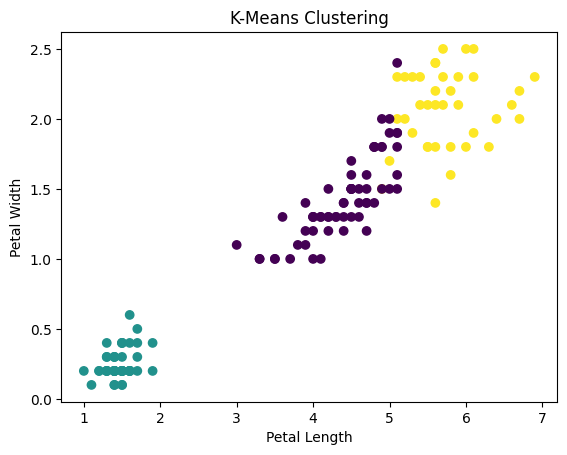

In [38]:
plt.scatter(
    iris['petal_length'],
    iris['petal_width'],
    c=iris['kmeans_cluster']
)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('K-Means Clustering')
plt.show()

In [39]:
print("Cluster Centers:")
print(kmeans.cluster_centers_)

Cluster Centers:
[[5.9016129  2.7483871  4.39354839 1.43387097]
 [5.006      3.428      1.462      0.246     ]
 [6.85       3.07368421 5.74210526 2.07105263]]


In [40]:
comparison = pd.crosstab(
    iris['species'],
    iris['kmeans_cluster']
)

print(comparison)

kmeans_cluster   0   1   2
species                   
setosa           0  50   0
versicolor      48   0   2
virginica       14   0  36


In [41]:
actual = iris['species']
cluster = iris['kmeans_cluster']
from sklearn.metrics import adjusted_rand_score

actual = iris['species']
cluster = iris['kmeans_cluster']

ari = adjusted_rand_score(actual, cluster)

print("Adjusted Rand Index:", ari)

Adjusted Rand Index: 0.7302382722834697


### interpretation
K-Means successfully divides the Iris dataset into three clusters based on the numerical features. The clusters can be compared with the actual Iris species using a contingency table and Adjusted Rand Index. The clustering generally separates Setosa very well, while Versicolor and Virginica show some overlap.

|        ARI | Interpretation         |
| ---------: | ---------------------- |
|          1 | Perfect clustering     |
| Close to 1 | Very good clustering   |
|   Around 0 | Random-level agreement |
|   Negative | Worse than random      |


## Hierarchical Clustering

In [42]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [43]:
linked = linkage(X, method='ward')

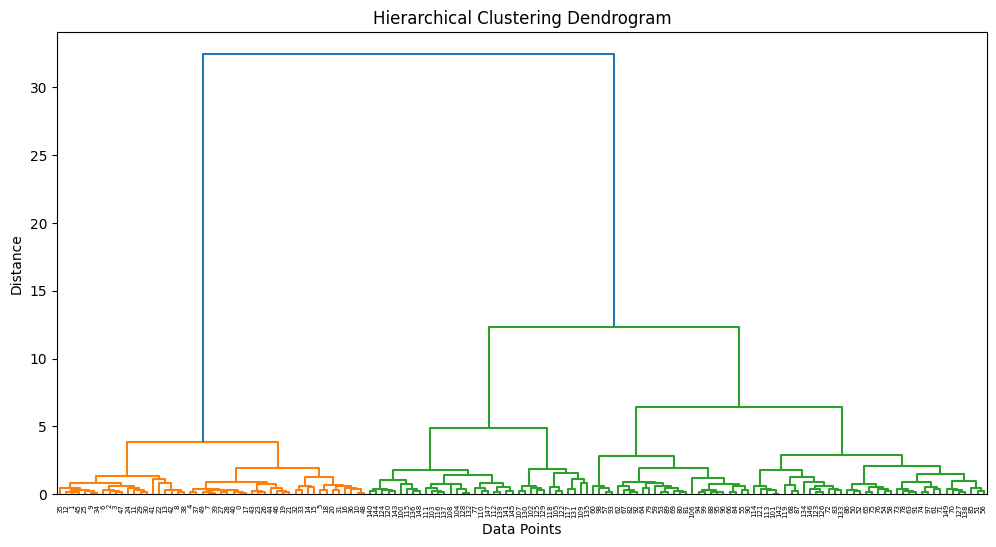

In [44]:
plt.figure(figsize=(12, 6))

dendrogram(linked)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')

plt.show()

In [45]:
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

hierarchical_labels = hierarchical.fit_predict(X)

In [46]:
iris['hierarchical_cluster'] = hierarchical_labels

print(
    iris[
        ['species', 'hierarchical_cluster']
    ].head(10)
)

  species  hierarchical_cluster
0  setosa                     1
1  setosa                     1
2  setosa                     1
3  setosa                     1
4  setosa                     1
5  setosa                     1
6  setosa                     1
7  setosa                     1
8  setosa                     1
9  setosa                     1


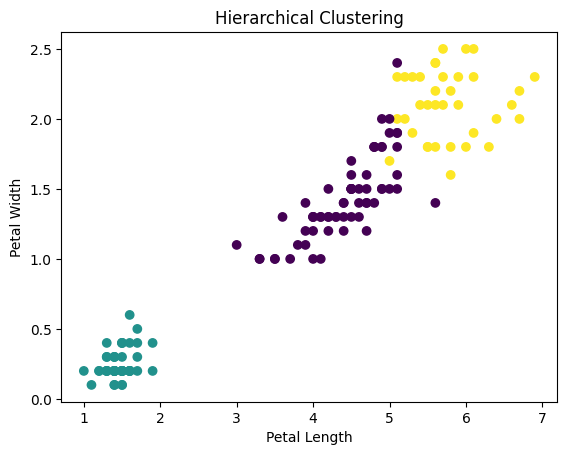

In [47]:
plt.scatter(
    iris['petal_length'],
    iris['petal_width'],
    c=iris['hierarchical_cluster']
)

plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Hierarchical Clustering')
plt.show()

In [48]:
comparison_hierarchical = pd.crosstab(
    iris['species'],
    iris['hierarchical_cluster']
)

print(comparison_hierarchical)

hierarchical_cluster   0   1   2
species                         
setosa                 0  50   0
versicolor            49   0   1
virginica             15   0  35


In [49]:
ari_hierarchical = adjusted_rand_score(
    iris['species'],
    iris['hierarchical_cluster']
)

print(
    "Hierarchical Clustering ARI:",
    ari_hierarchical
)

Hierarchical Clustering ARI: 0.7311985567707746


### interpretation
Hierarchical clustering also forms three groups that largely correspond to the actual Iris species. The dendrogram shows the hierarchical relationships between observations. Similar to K-Means, Setosa is generally well separated, while some overlap exists between Versicolor and Virginica.

# SECTION 3
### Cognitive Analytics

Build a Simple ML Model — Logistic Regression

We will build a Logistic Regression model to predict:

Survived = 0 or 1

Features we will use

pclass,sex,age,fare

Our target variable will be:

survived

In [50]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [51]:
data = titanic[
    ['pclass', 'sex', 'age', 'fare', 'survived']
].copy()

print(data.head())

   pclass     sex   age     fare  survived
0       3    male  22.0   7.2500         0
1       1  female  38.0  71.2833         1
2       3  female  26.0   7.9250         1
3       1  female  35.0  53.1000         1
4       3    male  35.0   8.0500         0


In [52]:
data['age'] = data['age'].fillna(data['age'].median())

In [53]:
data['sex'] = data['sex'].map({
    'male': 0,
    'female': 1
})

In [54]:
print(data.tail())

     pclass  sex   age   fare  survived
886       2    0  27.0  13.00         0
887       1    1  19.0  30.00         1
888       3    1  28.0  23.45         0
889       1    0  26.0  30.00         1
890       3    0  32.0   7.75         0


In [55]:
X = data[['pclass', 'sex', 'age', 'fare']]
y = data['survived']

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [57]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [58]:
y_pred = model.predict(X_test)

In [59]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


In [60]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[90 15]
 [20 54]]


In [61]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



# Compare Classical Tests vs ML Approaches
| Basis                  | Classical Statistical Tests                        | Machine Learning                                                          |
| ---------------------- | -------------------------------------------------- | ------------------------------------------------------------------------- |
| **Examples**           | T-test, Chi-square, ANOVA                          | Logistic Regression                                                       |
| **Main purpose**       | Test hypotheses and find relationships/differences | Make predictions                                                          |
| **Approach**           | Starts with a hypothesis                           | Learns patterns from data                                                 |
| **Output**             | Test statistic, p-value, confidence/significance   | Predictions, accuracy, precision, recall, F1-score                        |
| **Decision**           | Usually based on p-value or critical value         | Based on model performance                                                |
| **Variables**          | Often focuses on specific variables                | Can use multiple features together                                        |
| **Data splitting**     | Usually does not require train/test split          | Usually uses training and testing data                                    |
| **Interpretation**     | "Is there a significant difference/association?"   | "How accurately can we predict the outcome?"                              |
| **Example in our lab** | T-test: male vs female mean age                    | Logistic Regression: predict Titanic survival                             |
| **Strength**           | Good for statistical inference and explanation     | Good for prediction and pattern recognition                               |
| **Limitation**         | Often requires assumptions about data              | Good prediction does not necessarily mean causal/statistical significance |


# Section 4: Report and Findings

## Overview

In this experiment, statistical hypothesis testing, clustering,
and machine learning techniques were applied to the Iris and
Titanic datasets.

## Hypothesis Testing

An independent two-sample T-test was performed on the Titanic
dataset to compare the mean age of male and female passengers.
The test indicated a statistically significant difference between
the two groups.

A Chi-square test was performed on the Iris dataset to examine
the relationship between Iris species and sepal-length categories.
The result indicated a significant association between the two
categorical variables.

A one-way ANOVA was performed to compare the mean sepal length
among Setosa, Versicolor, and Virginica. The calculated F-statistic
was much greater than the critical value, so the null hypothesis
was rejected. Therefore, there is a significant difference in mean
sepal length among the three species.

## Clustering Analysis

K-Means clustering was applied to the Iris dataset using three
clusters. The clusters showed good separation, particularly for
Setosa. The Adjusted Rand Index was approximately 0.73, indicating
fairly good agreement between the discovered clusters and the
actual species labels.

Hierarchical clustering was also applied using Ward's linkage.
The dendrogram showed that the Iris observations can be divided
into approximately three major groups.

## Machine Learning

A Logistic Regression model was developed to predict Titanic
passenger survival using passenger class, gender, age, and fare.
The data was divided into training and testing sets, and the model
was evaluated using accuracy and a confusion matrix.

## Classical Statistics vs Machine Learning

Classical statistical tests primarily focus on hypothesis testing,
statistical significance, and understanding relationships in data.
They use measures such as test statistics, p-values, and critical
values.

Machine learning focuses primarily on learning patterns from data
and making predictions on unseen observations. Model performance
can be evaluated using accuracy, precision, recall, and F1-score.

## Real-World Applications

These techniques have applications in business, healthcare,
finance, marketing, and engineering. Hypothesis tests can be used
to determine whether observed differences are statistically
significant, clustering can be used for customer segmentation,
and machine learning can be used for prediction and automated
decision-making.

## Conclusion

The experiment demonstrated how statistical analysis, clustering,
and machine learning can be combined to analyze datasets.
Statistical tests help explain relationships and determine
statistical significance, while clustering discovers natural
groups in data and machine learning provides predictive
capabilities.